In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

from blackhole.constants import ALPHA_COLD, M_sun
from blackhole.cr_solvers import h_2, solve_cr_structure
from blackhole.steady_state import (
    H_inner,
    H_middle,
    H_outer,
    Sigma_inner,
    Sigma_middle,
    Sigma_outer,
    T_c_inner,
    T_c_middle,
    T_c_outer,
    border_inner_middle,
    border_middle_outer,
    r_g,
    r_hat,
    rho_inner,
    rho_middle,
    rho_outer,
    tau_inner,
    tau_middle,
    tau_outer,
    u_r_inner,
    u_r_middle,
    u_r_outer,
)
from blackhole.viscosity import alpha_visc

# --- Simulation parameters ---
M = 10 * M_sun          # Black hole mass (10 solar masses) — used for axis limits
M_CR = M_sun             # CR solver mass (1 solar mass)
M_dot_CR = 5e16          # CR solver accretion rate (g/s)
alpha = ALPHA_COLD       # Default alpha viscosity

In [2]:
# ---------------------------------------------------------------------------
# Plotting helpers — ported from GPU_cr_graph_normal_bh.ipynb,
# GPU_graphformulae_variablealpha_bath.ipynb, and
# diskequations_SS_bath_params.ipynb
# ---------------------------------------------------------------------------


def _make_T_midpoints(Tmin, Tmax, NPanels):
    """Create log-spaced temperature midpoint array."""
    Tlogarray = np.linspace(np.log10(Tmin), np.log10(Tmax), NPanels + 1)
    Tlogmidpoints = Tlogarray[:-1] + (Tlogarray[1] - Tlogarray[0]) / 2
    return 10**Tlogmidpoints


def Variable_plot(rmin, rmax, M_star, M_dot, NPanels, variable):
    """Plot a steady-state disk variable vs radius (Kramers-SS model).

    variable: 1=H, 2=Sigma, 3=rho, 4=u_r, 5=T_c, 6=tau
    """
    rlogarray = np.linspace(np.log10(rmin), np.log10(rmax), NPanels + 1)
    rlogmidpoints = rlogarray[:-1] + (rlogarray[1] - rlogarray[0]) / 2
    rmidpoints = 10**rlogmidpoints

    border_ab = border_inner_middle(alpha, M_star, M_dot)
    border_bc = border_middle_outer(M_dot)

    # Map variable index to (inner, middle, outer) function triples
    func_map = {
        1: (H_inner, H_middle, H_outer),
        2: (Sigma_inner, Sigma_middle, Sigma_outer),
        3: (rho_inner, rho_middle, rho_outer),
        4: (u_r_inner, u_r_middle, u_r_outer),
        5: (T_c_inner, T_c_middle, T_c_outer),
        6: (tau_inner, tau_middle, tau_outer),
    }
    f_inner, f_middle, f_outer = func_map[variable]

    result = np.empty(len(rmidpoints))
    for i, ri in enumerate(rmidpoints):
        rh = r_hat(ri, M_star)
        if rh < border_ab:
            result[i] = f_inner(ri, M_star, M_dot, alpha)
        elif rh > border_bc:
            result[i] = f_outer(ri, M_star, M_dot, alpha)
        else:
            result[i] = f_middle(ri, M_star, M_dot, alpha)

    plot = plt.plot(rmidpoints, result, label='Kramers - SS',
                    linestyle='dotted', color='black', linewidth=1.2)
    return plot


def rad_T_old_plot_2(Tmin, Tmax, r_guess, rho_guess, alpha_var, NPanels):
    """Plot T vs r using Kramers (old) opacity CR solver."""
    Tmidpoints = _make_T_midpoints(Tmin, Tmax, NPanels)
    r_arr, _ = solve_cr_structure(Tmidpoints, r_guess, rho_guess, alpha_var,
                                  M_star=M_CR, M_dot=M_dot_CR,
                                  use_old_opacity=True)
    plot = plt.plot(r_arr, Tmidpoints, linestyle='dashed',
                    label='Kramers - CR', color='r', linewidth=1.2)
    return plot


def rad_T_CR_plot_2(Tmin, Tmax, r_guess, rho_guess, alpha_var, NPanels):
    """Plot T vs r using fitted (total) opacity CR solver."""
    Tmidpoints = _make_T_midpoints(Tmin, Tmax, NPanels)
    r_arr, _ = solve_cr_structure(Tmidpoints, r_guess, rho_guess, alpha_var,
                                  M_star=M_CR, M_dot=M_dot_CR,
                                  use_old_opacity=False)
    plot = plt.plot(r_arr, Tmidpoints, linestyle='solid',
                    label='Fitted - CR', color='orange', linewidth=1.5)
    return plot


def rad_h_plot(Tmin, Tmax, r_guess, rho_guess, alpha_var, NPanels):
    """Plot h vs r using fitted opacity CR solver."""
    Tmidpoints = _make_T_midpoints(Tmin, Tmax, NPanels)
    r_arr, rho_arr = solve_cr_structure(Tmidpoints, r_guess, rho_guess,
                                        alpha_var, M_star=M_CR,
                                        M_dot=M_dot_CR, use_old_opacity=False)
    harray = np.array([h_2(r_arr[i], rho_arr[i], M_CR, M_dot_CR, Tmidpoints[i])
                        for i in range(len(Tmidpoints))])
    plot = plt.plot(r_arr, harray, linestyle='solid',
                    label='Fitted - CR', color='b', linewidth=1.8)
    return plot


def rad_h_old_plot(Tmin, Tmax, r_guess, rho_guess, alpha_var, NPanels):
    """Plot h vs r using Kramers opacity CR solver."""
    Tmidpoints = _make_T_midpoints(Tmin, Tmax, NPanels)
    r_arr, rho_arr = solve_cr_structure(Tmidpoints, r_guess, rho_guess,
                                        alpha_var, M_star=M_CR,
                                        M_dot=M_dot_CR, use_old_opacity=True)
    harray = np.array([h_2(r_arr[i], rho_arr[i], M_CR, M_dot_CR, Tmidpoints[i])
                        for i in range(len(Tmidpoints))])
    plot = plt.plot(r_arr, harray, linestyle='dashed',
                    label='Kramers - CR', color='r', linewidth=1.2)
    return plot


def T_Sigma_plot(Tmin, Tmax, r_guess, rho_guess, alpha_var, NPanels):
    """Plot T vs Sigma using fitted opacity CR solver."""
    Tmidpoints = _make_T_midpoints(Tmin, Tmax, NPanels)
    r_arr, rho_arr = solve_cr_structure(Tmidpoints, r_guess, rho_guess,
                                        alpha_var, M_star=M_CR,
                                        M_dot=M_dot_CR, use_old_opacity=False)
    Sigma_arr = np.array([
        2 * rho_arr[i] * h_2(r_arr[i], rho_arr[i], M_CR, M_dot_CR, Tmidpoints[i])
        for i in range(len(Tmidpoints))
    ])
    plot = plt.plot(Sigma_arr, Tmidpoints, linestyle='dashed', label=alpha_var)
    return plot


def T_Sigma_alphavar_plot(Tmin, Tmax, r_guess, rho_guess, NPanels):
    """Plot T vs Sigma using fitted opacity CR solver with variable alpha."""
    Tmidpoints = _make_T_midpoints(Tmin, Tmax, NPanels)
    alpha_arr = alpha_visc(Tmidpoints)
    r_arr, rho_arr = solve_cr_structure(Tmidpoints, r_guess, rho_guess,
                                        alpha_arr, M_star=M_CR,
                                        M_dot=M_dot_CR, use_old_opacity=False)
    Sigma_arr = np.array([
        2 * rho_arr[i] * h_2(r_arr[i], rho_arr[i], M_CR, M_dot_CR, Tmidpoints[i])
        for i in range(len(Tmidpoints))
    ])
    plot = plt.plot(Sigma_arr, Tmidpoints, linestyle='solid',
                    label='Variable', linewidth=2, color='k')
    return plot

CPU times: total: 36.2 s
Wall time: 37.4 s


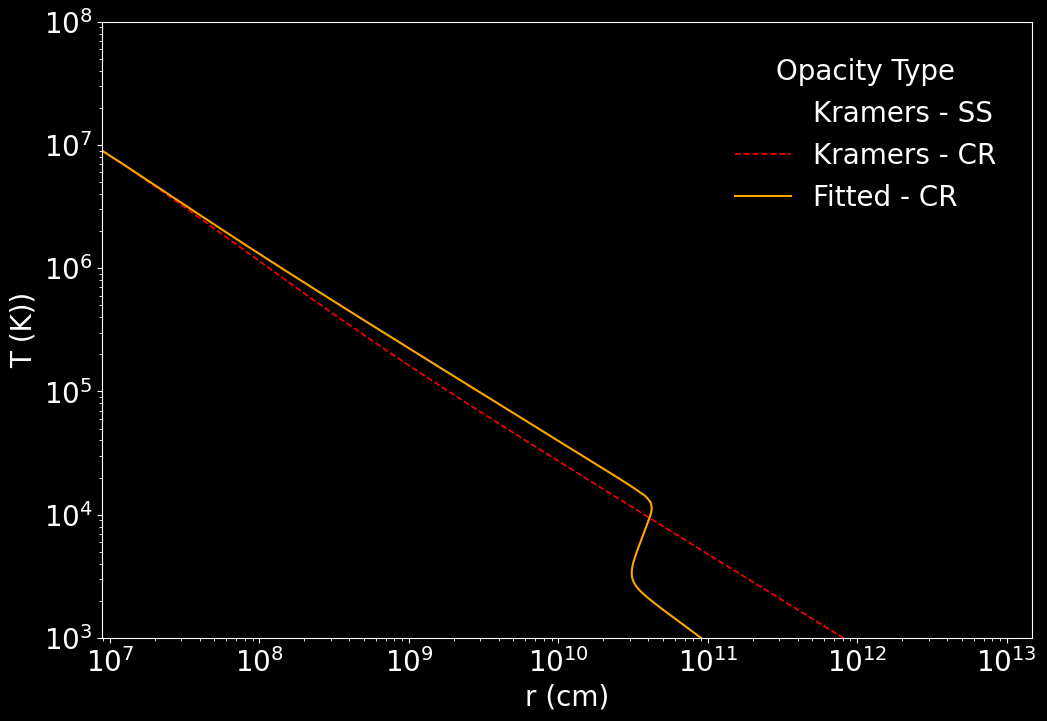

In [3]:
%%time
font = {'weight' : 'normal',
        'size'   : 20}

plt.rc('font', **font)
plt.figure(figsize=(12, 8))
plt.xlabel("r (cm)")
plt.ylabel("T (K))")
plt.yscale("log")
plt.xscale("log")
plt.xlim(r_g(M)*3, 1.48e13)
plt.ylim(1e3, 1e8)

Tmin = 1e2
Tmax = 1e8
r_guess = 1e8
rho_guess = 1e-7
NPanels_old = 10000
NPanels_CR = 20000
M1 = M_CR
Md1 = M_dot_CR

Variable_plot(r_g(M)*3, 1e19, M1, Md1, NPanels_old, 5)
rad_T_old_plot_2(Tmin, Tmax, 1e15, 1e-0, 0.4, NPanels_old)
rad_T_CR_plot_2(Tmin, Tmax, r_guess, rho_guess, 0.4, NPanels_CR)

plt.legend().remove()
plt.legend(loc='upper right', borderpad=0.8, title="Opacity Type", frameon=False)

    CPU times: total: 4.61 s    Wall time: 5.24 s        <matplotlib.legend.Legend at 0x1d5e78c9420>    ![png](../graphs/output_1_2.png)    

CPU times: total: 37.7 s
Wall time: 39.2 s


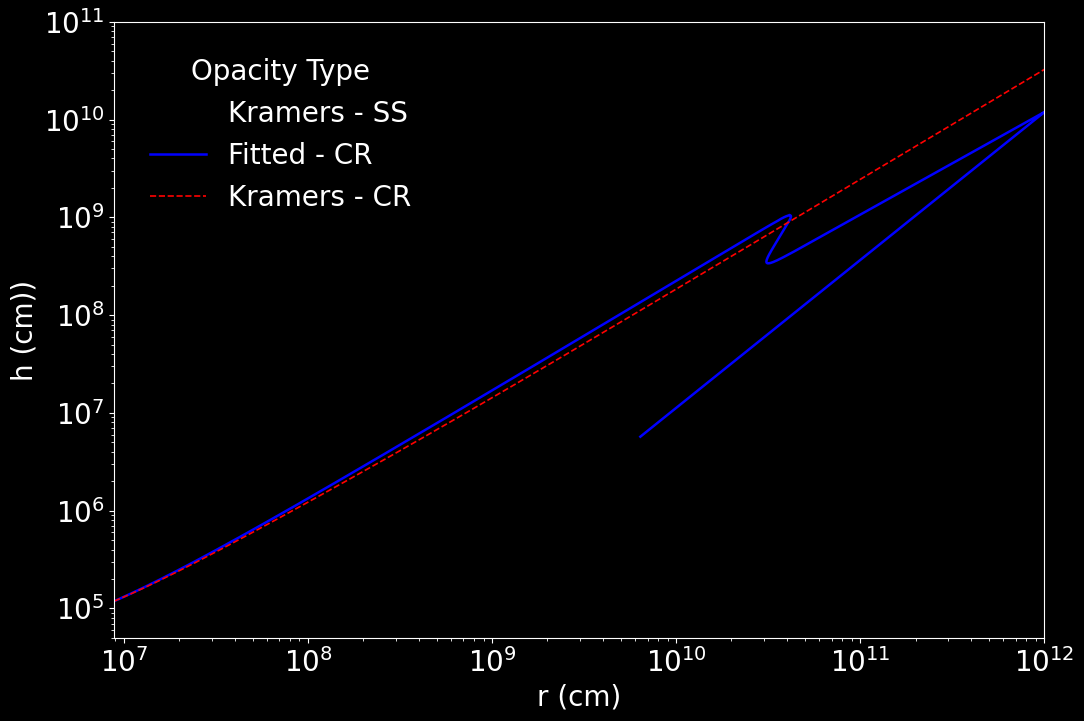

In [4]:
%%time
font = {'weight' : 'normal',
        'size'   : 20}

plt.rc('font', **font)
plt.figure(figsize=(12, 8))
plt.xlabel("r (cm)")
plt.ylabel("h (cm))")
plt.yscale("log")
plt.xscale("log")

plt.xlim(r_g(M)*3, 1e12)
plt.ylim(5e4, 1e11)

Tmin = 1e2
Tmax = 1e8
r_guess = 1e8
rho_guess = 1e-7
NPanels_old = 10000
NPanels_CR = 20000
M1 = M_CR
Md1 = M_dot_CR

Variable_plot(r_g(M)*3, 1e19, M1, Md1, NPanels_old, 1)
rad_h_plot(Tmin, Tmax, r_guess, rho_guess, 0.4, NPanels_CR)
rad_h_old_plot(Tmin, Tmax, r_guess, rho_guess, 0.4, NPanels_old)

plt.legend().remove()
plt.legend(loc='upper left', borderpad=0.8, title="Opacity Type", frameon=False)

    CPU times: total: 6.36 s    Wall time: 7.15 s        <matplotlib.legend.Legend at 0x1d5e34412a0>    ![png](../graphs/output_2_2.png)    

CPU times: total: 2min 17s
Wall time: 2min 22s


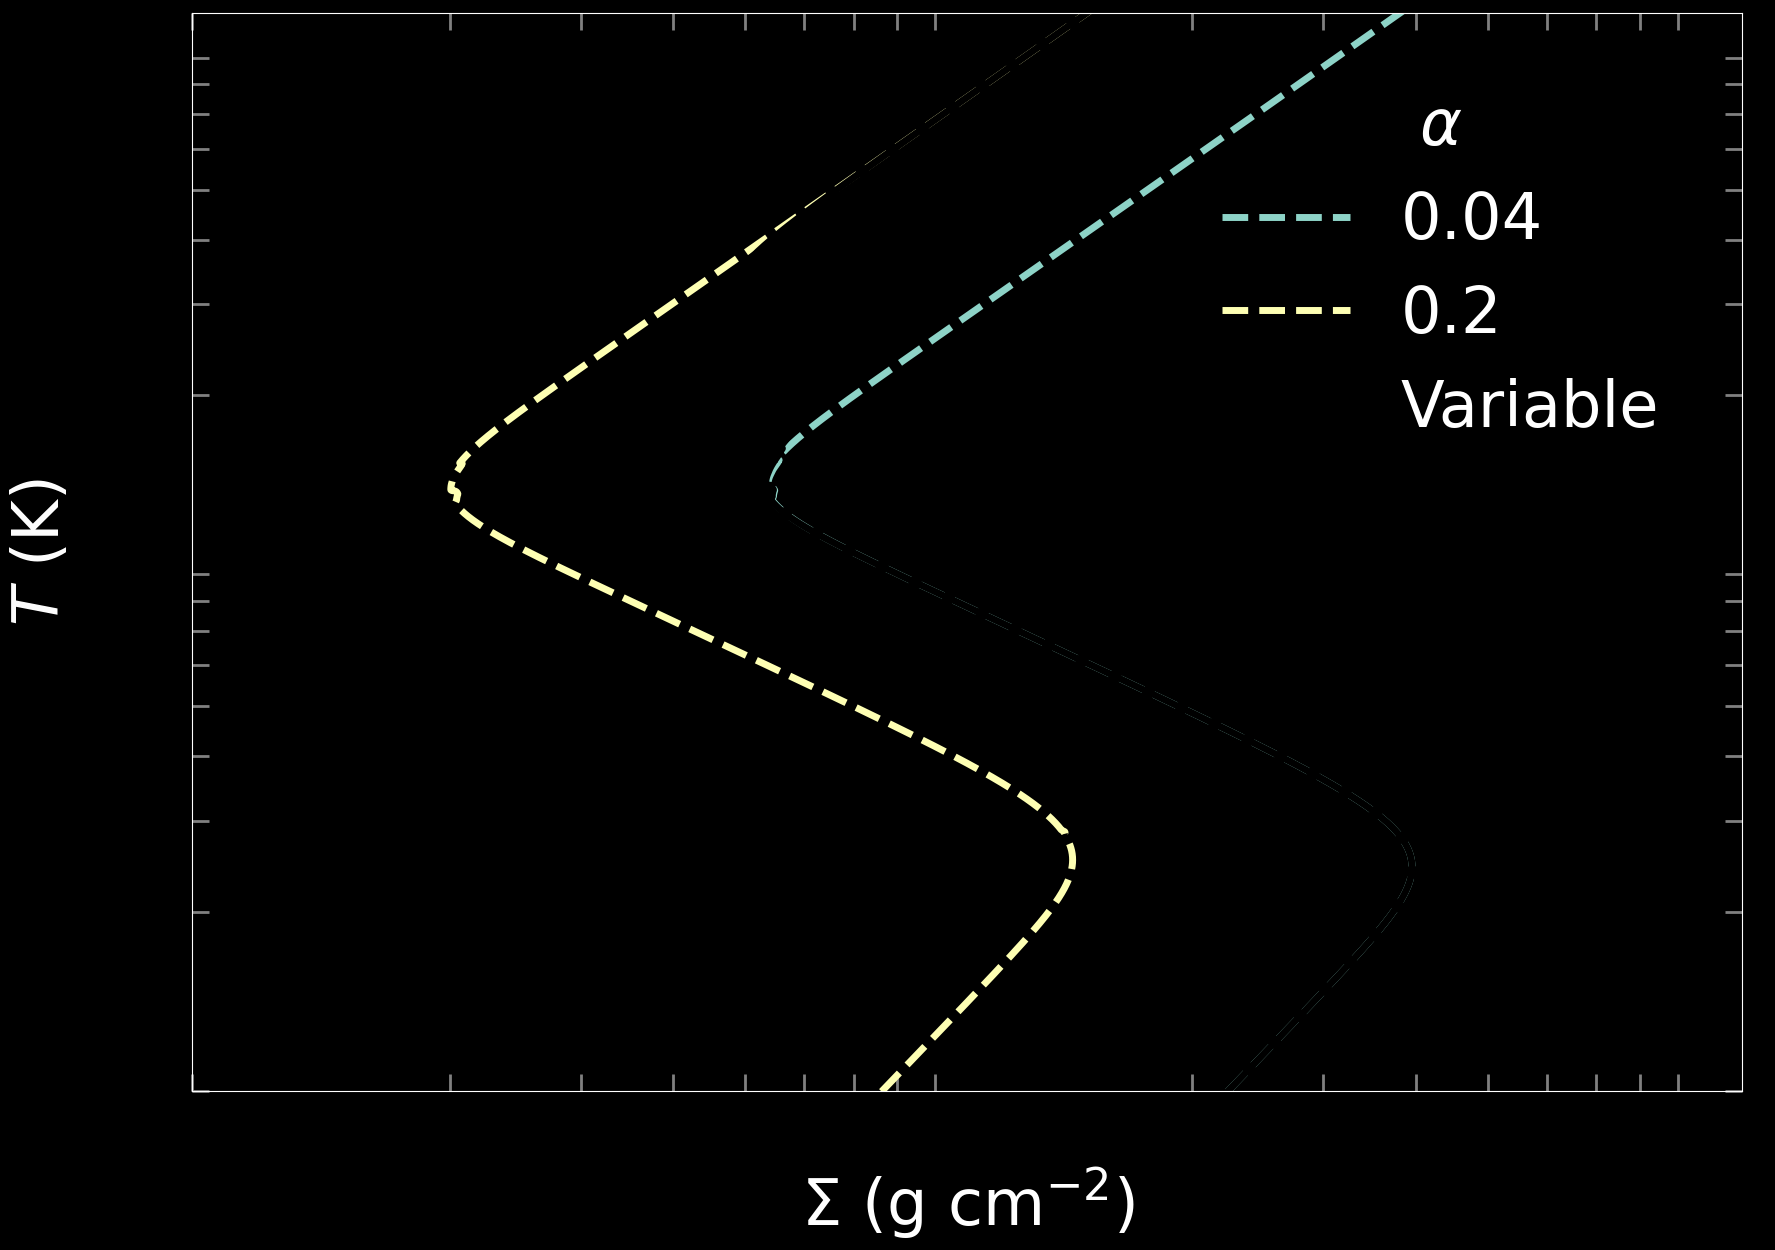

In [5]:
%%time
font = {'weight' : 'normal',
        'size'   : 46}

plt.rc('font', **font)
plt.figure(figsize=(20, 14))
plt.xlabel(r"$\Sigma$ (g cm$^{-2}$)")
plt.ylabel(r"$T$ (K)")
plt.yscale("log")
plt.xscale("log")
plt.minorticks_on()
plt.tick_params(axis='both', which='major', direction='in', length=24, width=2, colors='black')
plt.tick_params(axis='both', which='minor', direction='in', length=12, width=2, colors='gray')
plt.tick_params(axis='both', which='both', top=True, right=True, direction='in')
plt.tick_params(labeltop=False, labelright=False)

plt.xlim(0.9e1, 1.1e3)
plt.ylim(.9e3, 1.1e5)

Tmin = 1e1
Tmax = 1e6
r_guess = 1e11
rho_guess = 1e-8
NPanels = 35000

plot1 = T_Sigma_plot(Tmin, Tmax, r_guess, rho_guess, 0.04, NPanels)[0]
plot2 = T_Sigma_plot(Tmin, Tmax, r_guess, rho_guess, 0.2, NPanels)[0]
plot3 = T_Sigma_alphavar_plot(Tmin, Tmax, r_guess, rho_guess, NPanels)[0]
plot1.set_linewidth(5)
plot2.set_linewidth(5)
plot3.set_linewidth(5)
plt.legend(loc='upper right', borderpad=0.8, title=r"$\alpha$", frameon=False)

    CPU times: total: 24.2 s    Wall time: 28.9 s        <matplotlib.legend.Legend at 0x1830e995c00>    ![png](../graphs/output_3_2.png)    

In [6]:
vTlogarray = np.linspace(np.log10(Tmin), np.log10(Tmax), NPanels + 1)
vTarray = 10**vTlogarray

vTlogmidpoints = vTlogarray + (vTlogarray[1] - vTlogarray[0]) / 2
vTlogmidpoints = np.delete(vTlogmidpoints, len(vTlogmidpoints) - 1)
vTmidpoints = 10**vTlogmidpoints

valpha_var = np.empty(len(vTmidpoints))
valpha_var = alpha_visc(vTmidpoints)

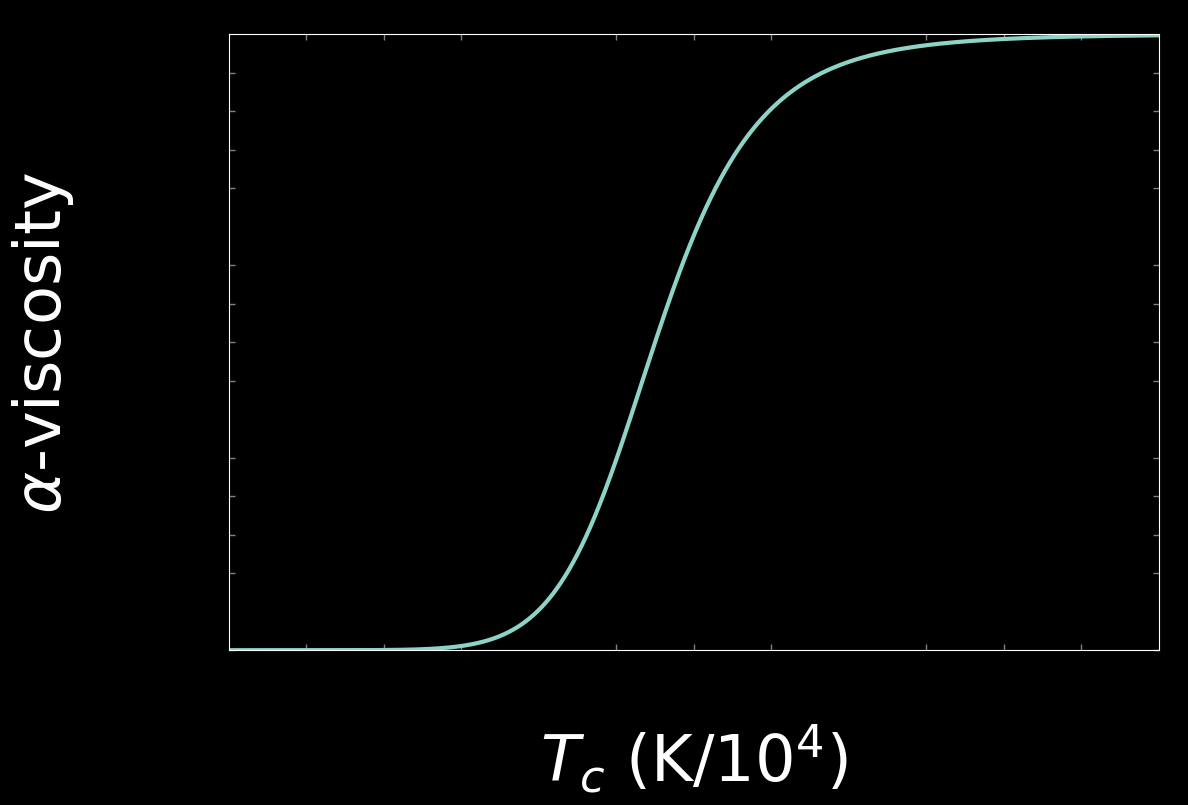

In [7]:
def plot_alphat(T_c, alpha_v):
    y_values = np.asarray(alpha_v)
    x_values = np.asarray(T_c / 1e4)
    plt.figure(figsize=(12, 8))
    plt.plot(x_values, y_values, linewidth=3)
    plt.xlabel(r'$T_c$ (K/$10^4$)')
    plt.ylabel(r'$\alpha$-viscosity')
    plt.minorticks_on()
    plt.tick_params(axis='both', which='major', direction='in', length=8, width=1, colors='black')
    plt.tick_params(axis='both', which='minor', direction='in', length=4, width=1, colors='gray')
    plt.tick_params(axis='both', which='both', top=True, right=True, direction='in')
    plt.tick_params(labeltop=False, labelright=False)  # Hide labels on top and right
    plt.xlim(0, 6)
    plt.ylim(0.04, 0.2)
    plt.show()

# Call the plotting function
plot_alphat(vTmidpoints, valpha_var)

    ![png](../graphs/output_5_0.png)    